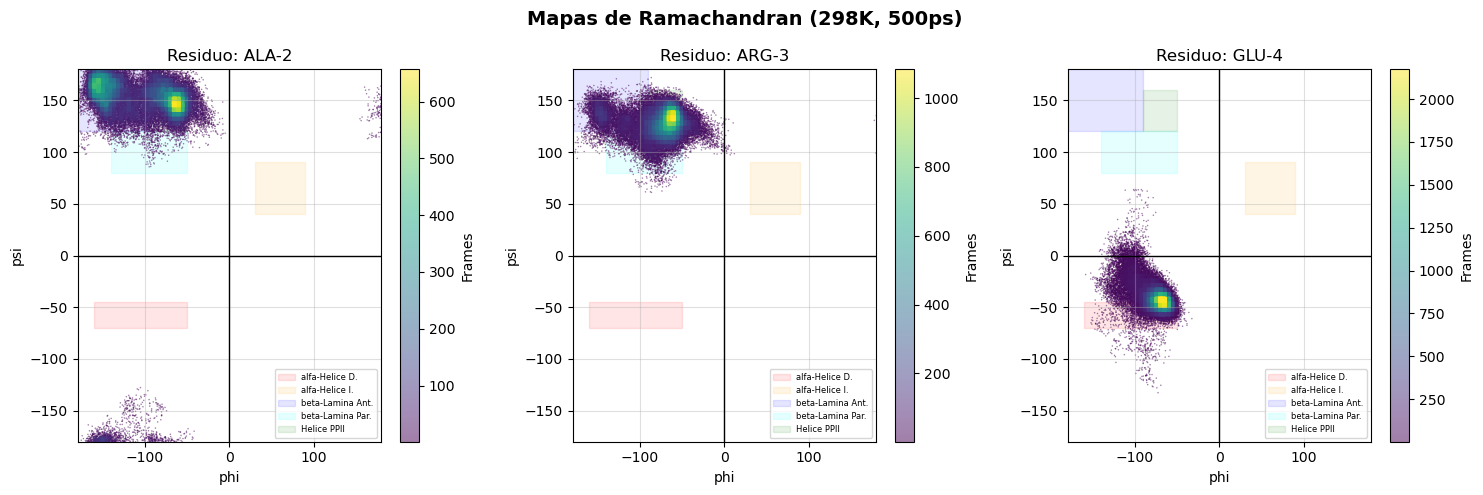


REGIÓN             | ALA-2        | ARG-3        | GLU-4       
--------------------------------------------------------------------------------
alfa-Helice D.     |    0.0%      |    0.0%      |   37.7%     
alfa-Helice I.     |    0.0%      |    0.0%      |    0.0%     
beta-Lamina Ant.   |   52.6%      |   17.6%      |    0.0%     
beta-Lamina Par.   |    1.2%      |   21.8%      |    0.0%     
Helice PPII        |   32.0%      |   52.0%      |    0.0%     


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.path import Path

#CONFIGURACIÓN
archivos = [
    ("/home/alumno23/MM/for-students/TAREA_PERFECTA/extended/ala-2.dat", "ALA-2"),
    ("/home/alumno23/MM/for-students/TAREA_PERFECTA/extended/arg-3.dat", "ARG-3"),
    ("/home/alumno23/MM/for-students/TAREA_PERFECTA/extended/glu-4.dat", "GLU-4")
]

#Regiones añadidas al gráfico con mayor transparencia
regiones = [
    {'name': 'alfa-Helice D.', 'coords': [[-160, -45], [-50, -45], [-50, -70], [-160, -70]], 'color': 'red'},
    {'name': 'alfa-Helice I.', 'coords': [[30, 40], [90, 40], [90, 90], [30, 90]], 'color': 'orange'},
    {'name': 'beta-Lamina Ant.', 'coords': [[-180, 120], [-180, 180], [-90, 180], [-90, 120]], 'color': 'blue'},
    {'name': 'beta-Lamina Par.', 'coords': [[-140, 80], [-140, 120], [-50, 120], [-50, 80]], 'color': 'cyan'},
    {'name': 'Helice PPII', 'coords': [[-90, 120], [-90, 160], [-50, 160], [-50, 120]], 'color': 'green'}
]

datos_lista = []

#GRÁFICOS
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Mapas de Ramachandran (298K, 500ps)", fontweight='bold', fontsize=14)

for i, (path, nombre) in enumerate(archivos):
    try:
        data = np.loadtxt(path)
        phi, psi = data[:, 1], data[:, 2]
        datos_lista.append((nombre, phi, psi))

        counts, xedges, yedges = np.histogram2d(phi, psi, bins=80, range=[[-180, 180], [-180, 180]])
        ix = np.clip(np.searchsorted(xedges, phi) - 1, 0, len(xedges) - 2)
        iy = np.clip(np.searchsorted(yedges, psi) - 1, 0, len(yedges) - 2)
        dens = counts[ix, iy]
        sort = dens.argsort()

        ax = axs[i]
        for reg in regiones:
            ax.add_patch(Polygon(reg['coords'], closed=True, color=reg['color'], alpha=0.1, label=reg['name']))

        sc = ax.scatter(phi[sort], psi[sort], c=dens[sort], s=1.2, cmap='viridis', alpha=0.5, edgecolor='none')
        
        ax.set_title(f"Residuo: {nombre}")
        ax.set_xlabel("phi"); ax.set_ylabel("psi")
        ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
        ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
        ax.grid(alpha=0.4)
        ax.legend(loc='lower right', fontsize=6)
        plt.colorbar(sc, ax=ax).set_label('Frames')

    except Exception as e:
        print(f"Error en {nombre}: {e}")

plt.tight_layout()
plt.show()

#PRINT CONFORMACIONES
print("\n" + "="*80)
# Cabecera con los nombres de los residuos
print(f"{'REGIÓN':<18} | {'ALA-2':<12} | {'ARG-3':<12} | {'GLU-4':<12}")
print("-" * 80)

#Cálculo de los porcentajes para cada región
stats = []
for reg in regiones:
    fila_porcentajes = []
    p = Path(reg['coords'])
    
    for nombre, phi, psi in datos_lista:
        total = len(phi)
        dentro = np.sum(p.contains_points(np.vstack([phi, psi]).T))
        porcentaje = (dentro / total) * 100
        fila_porcentajes.append(f"{porcentaje:>6.1f}%")
    
    print(f"{reg['name']:<18} | {fila_porcentajes[0]:<12} | {fila_porcentajes[1]:<12} | {fila_porcentajes[2]:<12}")

print("="*80)